# iTracer
 2901 lineage traced cells

**kernel.**
- SImilarity Kernel: $K_{\mathrm{expr}}(i,j)=\exp(-d_{ij}^2/\sigma_i\sigma_j)$ on $i$'s
  own $k = 15$ nearest neighbours and $0$ elsewhere
- Lineage Kernel:
  $d^{\mathrm{lin}}_{ij}=\mathbf 1[\mathrm{bf}_i\neq\mathrm{bf}_j]+\mathbf
  1[\mathrm{sf}_i\neq\mathrm{sf}_j]\in\{0,1,2\}$,
  $R_{ij}=1-d^{\mathrm{lin}}_{ij}/2$,  $K_{\mathrm{lineage}}(i,j)=\exp(\beta R_{ij})$
  with $\beta=3$: same scar family $e^{3}\approx20\times$, same barcode only
  $e^{1.5}\approx4.5\times$, unrelated $1$;
- Velocity Kernel: $C_{ij}=\cos(v_i,\,g_j-g_i)$ with $v$ the scVelo velocity
  and $g$ the smoothed spliced counts
  $K_{\mathrm{velocity}}(i,j)=\exp(\nu C_{ij})$ with $\nu=\beta=3$.

$$W=K_{\mathrm{expr}}\odot K_{\mathrm{lineage}}\odot K_{\mathrm{velocity}},\qquad
P=\mathrm{diag}(W\mathbf 1)^{-1}W.$$


In [1]:
import pathlib
import sys

_here = pathlib.Path.cwd().resolve()
PUBLIC = next((p for p in (_here, *_here.parents)
               if (p / "scripts").is_dir() and (p / "notebooks").is_dir()), None)
assert PUBLIC is not None, "run this from inside the repo's public/ tree"
sys.path.insert(0, str(PUBLIC))

import warnings

import numpy as np
import pandas as pd
from IPython.display import Image, display

from scripts.core.itracer_data import (MIN_SCAR_CELLS, N_THIRDS, load_cloud, scar_is_edited)
from scripts.core.paths import figure_dir, rel
from scripts.experiments.itracer import bench
from scripts.experiments.itracer import figures as ifig
from scripts.experiments.itracer import tune as itune
from scripts.method import Run

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)

cfg = Run.from_env(n_steps=bench.N_STEPS, dtype=bench.DTYPE)
OUT = pathlib.Path(figure_dir(cfg.smoke))
c = load_cloud()
s, third, X = c.s, c.third, c.X

print(f"{cfg}")
print(f"R2 hindbrain x CG3-1, day 60: {len(s)} lineage-recorded cells of the "
      f"{c.diag['n_all']}-cell section, in {X.shape[1]} PCs")
print(f"lineage: {pd.Series(c.family).nunique()} scar families (> {MIN_SCAR_CELLS} cells) inside "
      f"{pd.Series(c.barcode).nunique()} barcode families; "
      f"{int(scar_is_edited(c.scar).sum())} of {len(c.scar)} cells carry an edited scar")
print(f"pseudotime: corr(s, neuron - NPC score) = {np.corrcoef(s, c.score)[0, 1]:.3f}, "
      f"tertiles at s = {c.edges[0]:.3f} / {c.edges[1]:.3f}")
print("\n" + pd.DataFrame(
    [{"third": ("p0 (early)", "withheld (middle)", "p1 (late)")[b],
      "cells": int((third == b).sum()),
      "s": f"{s[third == b].min():.3f} - {s[third == b].max():.3f}",
      "NPC-like": int((c.score[third == b] < 0).sum()),
      "neuron-like": int((c.score[third == b] >= 0).sum()),
      "scar families": int(pd.Series(c.family[third == b]).nunique()),
      "barcode families": int(pd.Series(c.barcode[third == b]).nunique())}
     for b in range(N_THIRDS)]).to_string(index=False))


device cuda   seeds (0, 1, 2)   smoke False   iters 2500/1500/1500
R2 hindbrain x CG3-1, day 60: 2901 lineage-recorded cells of the 29274-cell section, in 50 PCs
lineage: 9 scar families (> 50 cells) inside 3 barcode families; 2901 of 2901 cells carry an edited scar
pseudotime: corr(s, neuron - NPC score) = 0.943, tertiles at s = 0.334 / 0.667

            third  cells             s  NPC-like  neuron-like  scar families  barcode families
       p0 (early)    967 0.000 - 0.333       961            6              9                 3
withheld (middle)    967 0.334 - 0.667       313          654              9                 3
        p1 (late)    967 0.667 - 1.000         0          967              9                 3


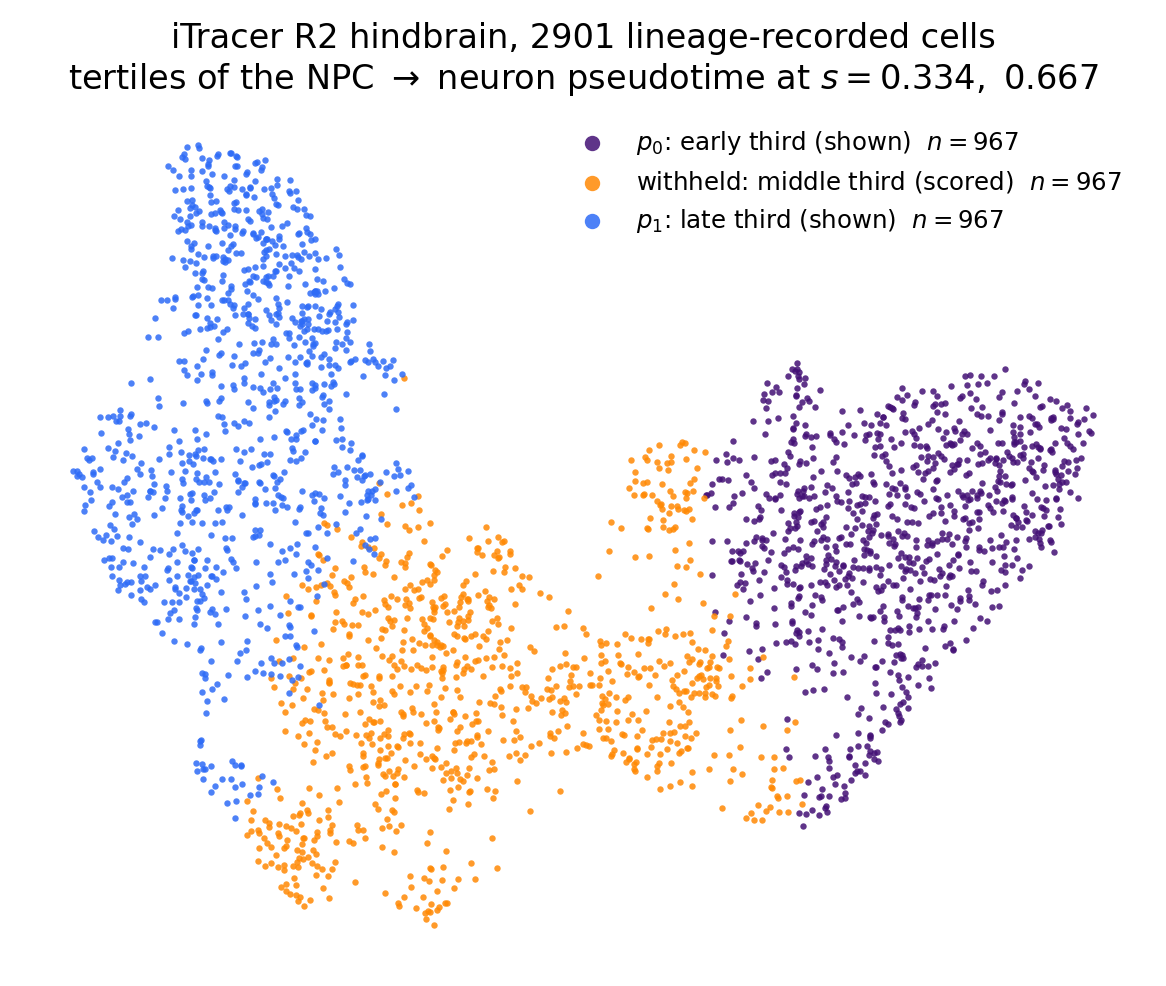

In [2]:
display(Image(filename=f"{ifig.figure_data(c, str(OUT))}.png"))

In [3]:
DIMS_RUN, SEEDS_RUN = bench.DIMS, (0,) if cfg.smoke else bench.SEEDS
POINTS_RUN = ("tuned",)

SEARCHED = itune.load_tuned()
assert SEARCHED, "scripts/experiments/itracer/tuned.json is missing; run `tune collect`"

print(f"{len(DIMS_RUN)} spaces x {len(bench.ARMS)} arms x {len(SEEDS_RUN)} seeds, "
      f"{bench.N_STEPS} integration steps, t_mid = {bench.snap(bench.t_mid(c)):.4f}, "
      f"dtype {bench.DTYPE}")
for d in DIMS_RUN:
    for a in bench.ARMS:
        print(f"  d = {d:<3} {bench.ARM_LABEL[a]:<28} {SEARCHED[d][a]}")
print(f"records -> {rel(bench.bench_root(cfg.smoke))}\n")

recs = bench.run_all(dims=DIMS_RUN, arms=bench.ARMS, seeds=SEEDS_RUN, points=POINTS_RUN, cfg=cfg)
print(f"\n{len(recs)} runs on {recs[0]['device']}")


3 spaces x 6 arms x 3 seeds, 300 integration steps, t_mid = 0.5000, dtype torch.float64
  d = 2   OT-CFM                       {'blur_frac': 0.0003}
  d = 2   MFM / LAND                   {'land_gamma': 0.0125}
  d = 2   FFM, expression-only P       {'rho_mult': 0.03, 'lam_mult': 0.0001}
  d = 2   FFM, + velocity              {'rho_mult': 0.0001, 'lam_mult': 0.0003}
  d = 2   FFM (ours), + lineage        {'rho_mult': 0.1, 'lam_mult': 0.001}
  d = 2   FFM, + lineage + velocity    {'rho_mult': 0.03, 'lam_mult': 0.0003}
  d = 20  OT-CFM                       {'blur_frac': 0.001}
  d = 20  MFM / LAND                   {'land_rho': 0.3}
  d = 20  FFM, expression-only P       {'rho_mult': 0.001, 'lam_mult': 10.0}
  d = 20  FFM, + velocity              {'rho_mult': 3e-05, 'lam_mult': 30.0}
  d = 20  FFM (ours), + lineage        {'rho_mult': 0.01, 'lam_mult': 30.0}
  d = 20  FFM, + lineage + velocity    {'rho_mult': 0.0003, 'lam_mult': 30.0}
  d = 50  OT-CFM                       {'blur_frac':

In [4]:
_task = recs[0]["task"]
print(f"W2 to the marginal, mean +- sd over {len(SEEDS_RUN)} seed(s).  `withheld` is the "
      f"{_task['n_scored']} reported cells of the {_task['n_withheld']}-cell middle third "
      "(the other\n"
      f"{_task['n_selection']} are the tuner's selection slice); `endpoint` is the marginal "
      "every arm was trained to hit, and is a fit\ncheck -- an arm that misses t = 1 has "
      "not earned a reading at t_mid.")
print(bench.table(recs, dims=DIMS_RUN, arms=bench.ARMS, point="tuned",
                  delta_vs="ffm_expr").to_string())

w2 = lambda d, a, key: float(np.mean([r[key]["W2"] for r in recs
                                      if r["point"] == "tuned"
                                      and r["dim"] == d and r["arm"] == a]))
for d in DIMS_RUN:
    base = min(("cfm", "mfm_land"), key=lambda a: w2(d, a, "interpolation"))
    print(f"  d = {d:<3} withheld third: best baseline {bench.ARM_LABEL[base]:<12} "
          f"{w2(d, base, 'interpolation'):.4f}   FFM {w2(d, 'ffm', 'interpolation'):.4f}"
          f"   {100 * (w2(d, 'ffm', 'interpolation') / w2(d, base, 'interpolation') - 1):+.1f}%")


W2 to the marginal, mean +- sd over 3 seed(s).  `withheld` is the 867 reported cells of the 967-cell middle third (the other
100 are the tuner's selection slice); `endpoint` is the marginal every arm was trained to hit, and is a fit
check -- an arm that misses t = 1 has not earned a reading at t_mid.
                                     d = 2                                           d = 20                                           d = 50                                
                                  withheld         endpoint Δ vs ffm_expr          withheld         endpoint Δ vs ffm_expr          withheld          endpoint Δ vs ffm_expr
OT-CFM                     1.3631 ± 0.0368  0.1214 ± 0.0105        +21.0%  15.9054 ± 0.0804  5.7966 ± 0.0599        +23.7%  18.8807 ± 0.1172  11.0946 ± 0.1381        +13.1%
MFM / LAND                 1.3538 ± 0.0569  0.1444 ± 0.0152        +20.1%  15.1860 ± 0.4448  6.5091 ± 0.1351        +18.1%  18.3308 ± 0.1287  11.5122 ± 0.0119         +9.8%
FFM, e

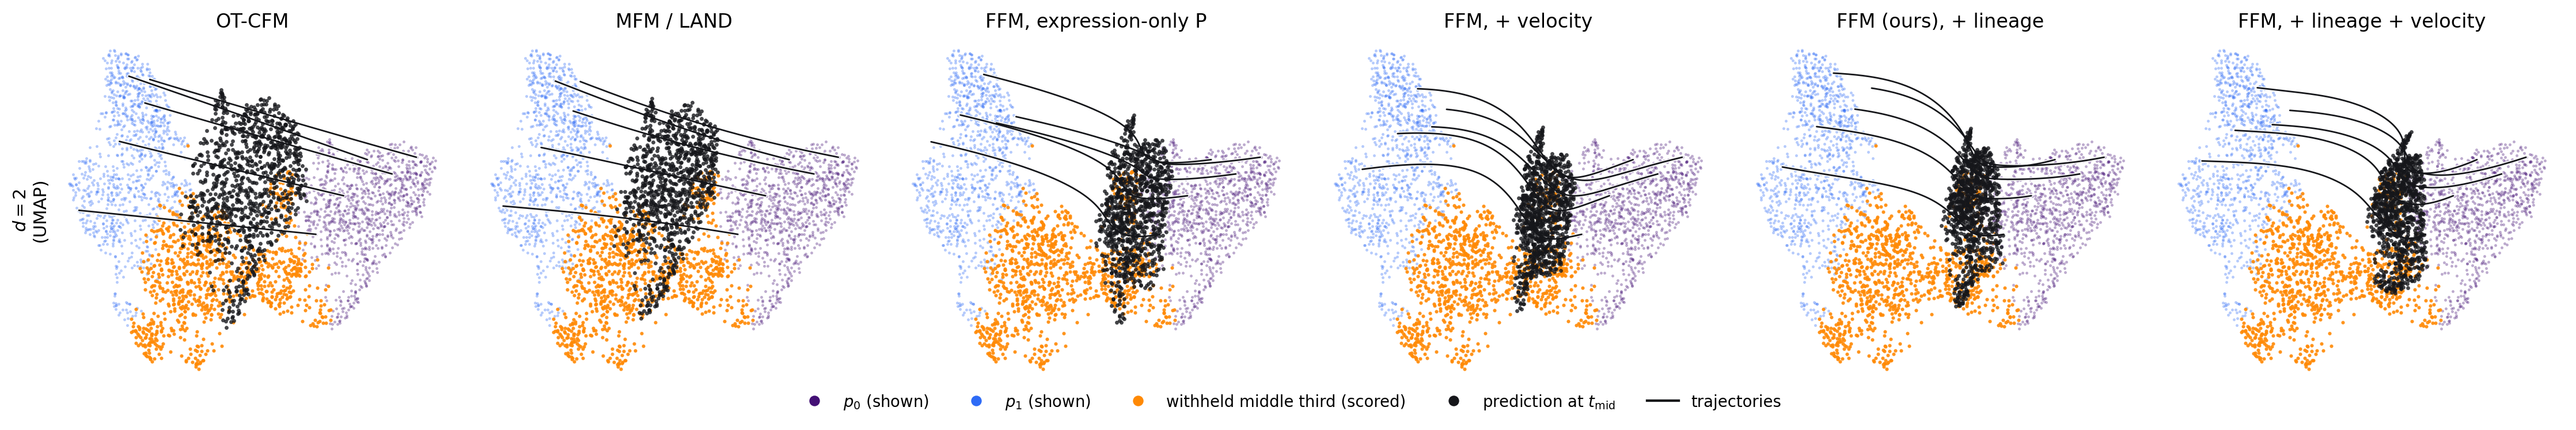

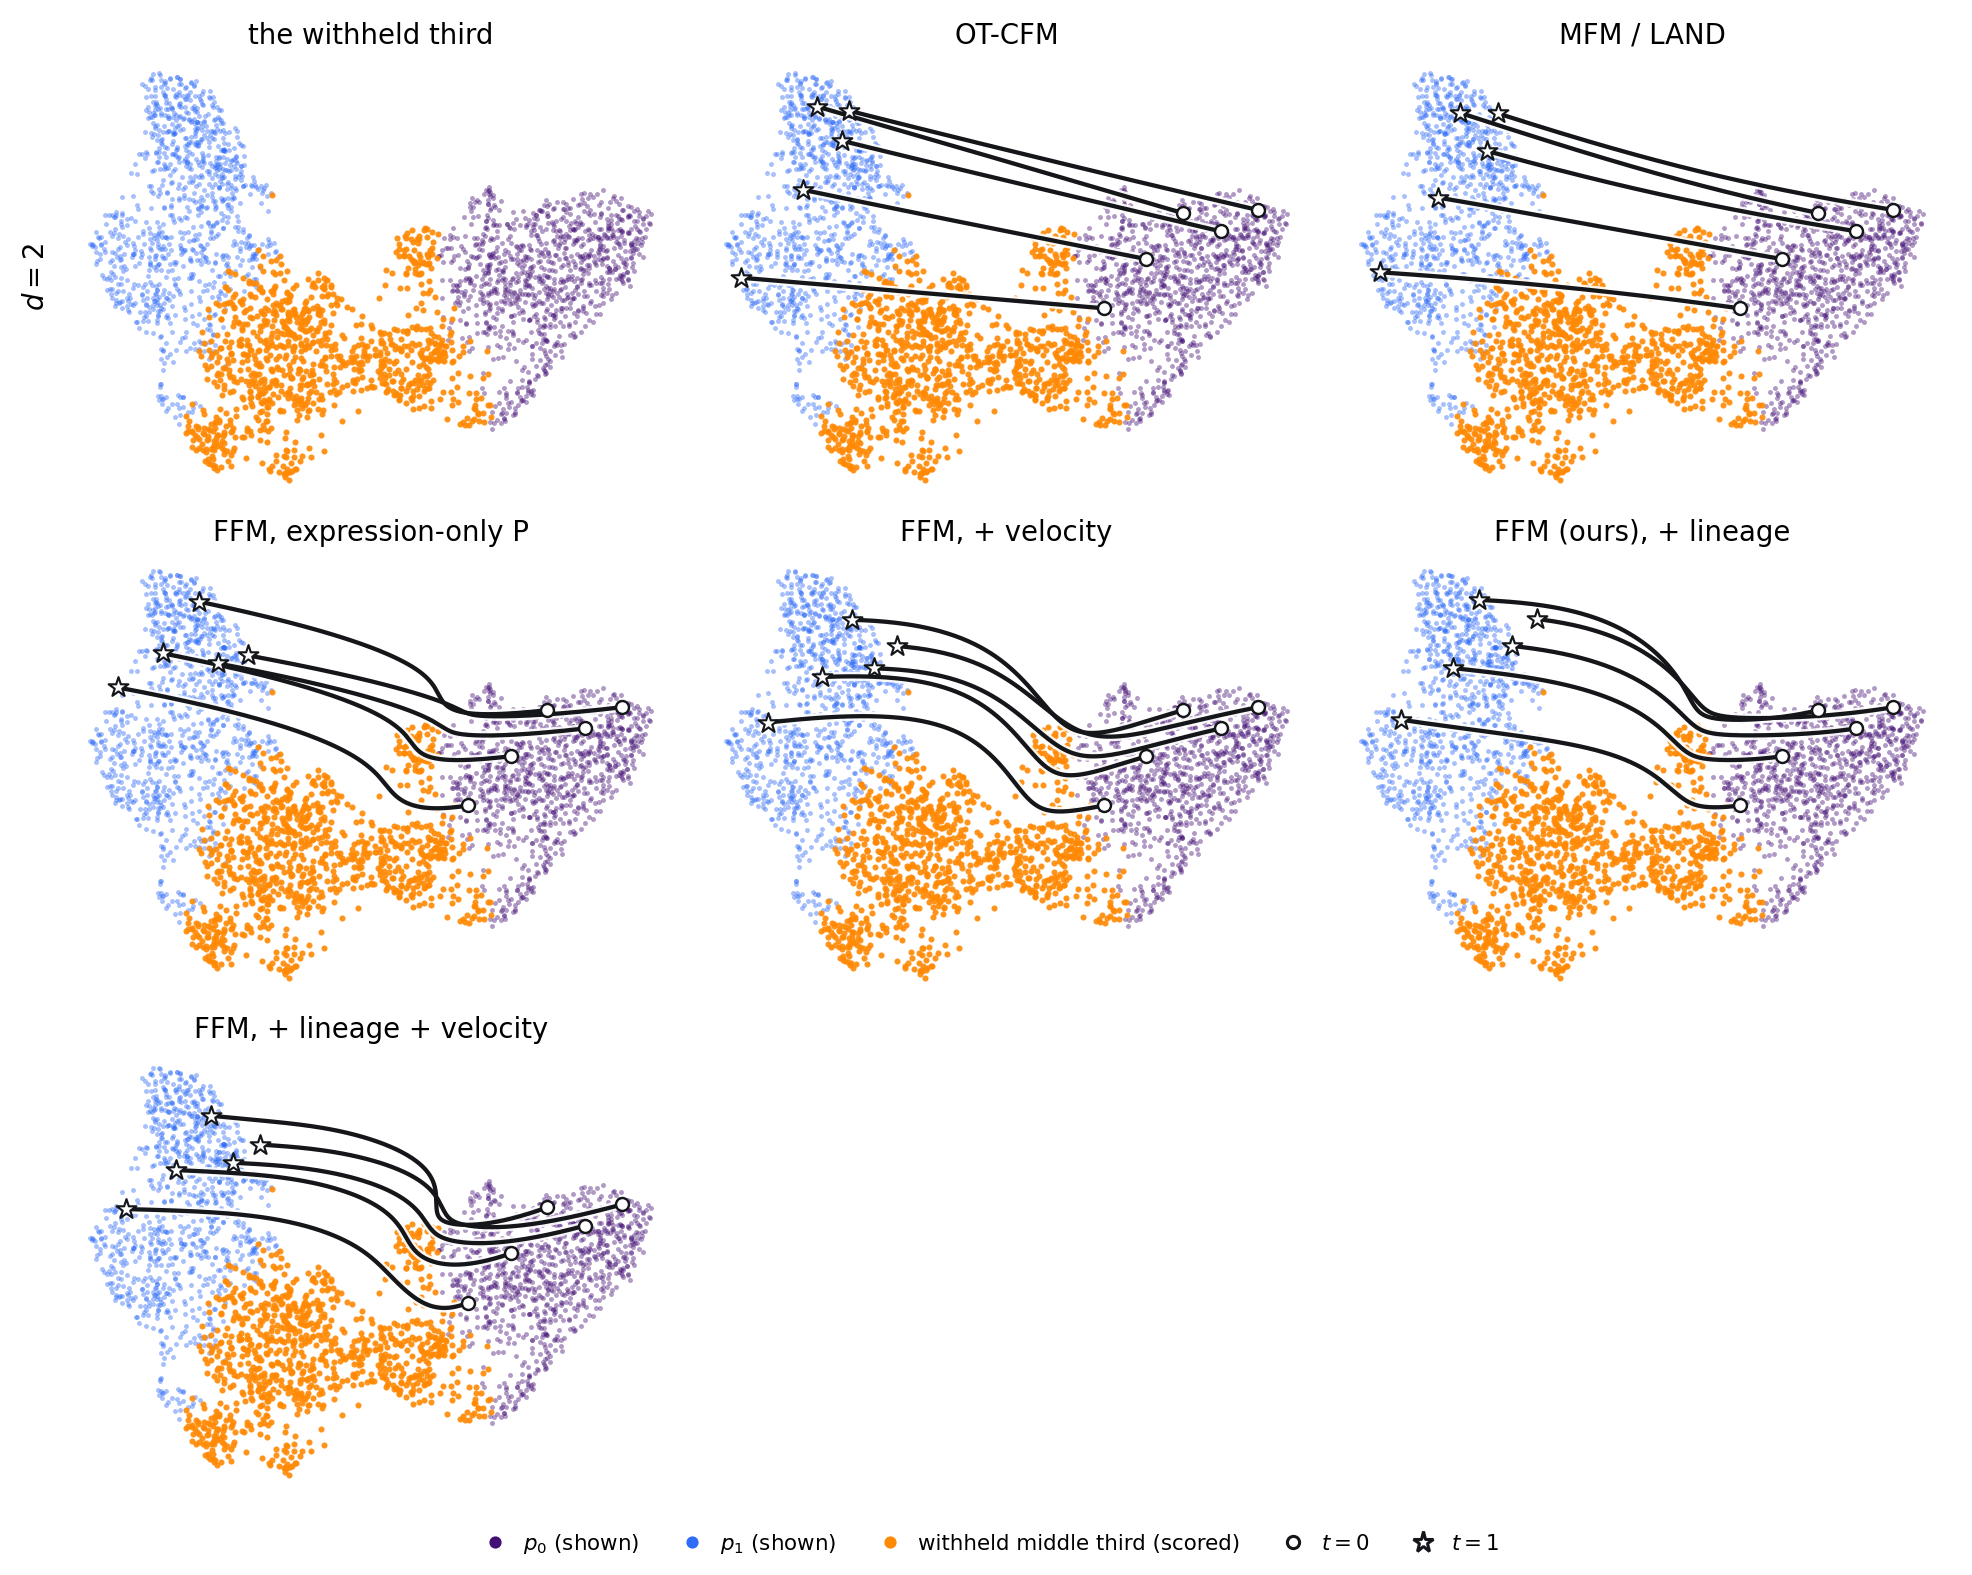

In [5]:
if bench.UMAP_DIM not in DIMS_RUN:
    print(f"no figure: d = {bench.UMAP_DIM} is not in DIMS_RUN = {DIMS_RUN}")
else:
    display(Image(filename=f"{ifig.figure_compare(c, (bench.UMAP_DIM,), bench.ARMS, str(OUT), seed=SEEDS_RUN[0], point='tuned', smoke=cfg.smoke)}.png"))
    display(Image(filename=f"{ifig.figure_paths(c, bench.ARMS, str(OUT), seed=SEEDS_RUN[0], point='tuned', smoke=cfg.smoke)}.png"))


In [6]:
SEEDS_MORE = (0,) if cfg.smoke else tuple(range(12))
recs_more = bench.run_all(dims=(bench.UMAP_DIM,), arms=bench.ARMS, seeds=SEEDS_MORE,
                          points=POINTS_RUN, cfg=cfg)
print(f"d = {bench.UMAP_DIM}, {len(SEEDS_MORE)} seeds")
print(bench.table(recs_more, dims=(bench.UMAP_DIM,), arms=bench.ARMS, point="tuned",
                  delta_vs="ffm_expr").to_string())

d = 2, 12 seeds
                                     d = 2                               
                                  withheld         endpoint Δ vs ffm_expr
OT-CFM                     1.3827 ± 0.0353  0.1208 ± 0.0180        +16.4%
MFM / LAND                 1.3632 ± 0.0347  0.1455 ± 0.0152        +14.8%
FFM, expression-only P     1.1879 ± 0.1068  0.2085 ± 0.0681         +0.0%
FFM, + velocity            1.0849 ± 0.1032  0.2261 ± 0.0781         -8.7%
FFM (ours), + lineage      1.1998 ± 0.0878  0.2275 ± 0.0474         +1.0%
FFM, + lineage + velocity  1.2877 ± 0.2669  0.3309 ± 0.3791         +8.4%
sampling floor                      0.1331           0.1297              
stay at p0                          1.7072                               
jump to p1                          1.9304                               
